## 12 Physical Pendulum with Air Resistance and Fourier Analysis

A pendulum consists of a metal ball tied to a string, described by the parameters below.  Model the pendulum,
and determine how the following physical phenomena affect the period of the motion:
1. Large angle calculation
3. Air resistance of the mass
4. Air resistance of the string
2. Moment of inertia of the mass




In [1]:
#File pendulumParameters.py

stringDiameter=0.00060 #meters
stringLength=0.664 #meters, from pivot to top of mass
stringDensity=0.00035/1 #kg/m
mMass=0.0235 #kg 
dMass=0.02539 #m diameter of mass, measured with caliper
stringMass=stringDensity*stringLength

#calculate length of pendulum
l=stringLength+dMass/2

#moments of Inertia
IMass=mMass*l*l  #moment of inertia of mass about pivot
IString=1.0/3*stringMass*stringLength**2 #1/3 mL**2 is Moment of intertia of rod about one end
I=IMass+IString

#center of mass
m=mMass+stringMass
lcm=(mMass*l+stringMass*stringLength/2)/m

print('Total Mass ',m)
print('lcm ',lcm,' l ',l)
print('I, IMass, IString:',I, IMass, IString)


Total Mass  0.0237324
lcm  0.673319567342536  l  0.676695
I, IMass, IString: 0.010795183634554168 0.010761028891087501 3.415474346666667e-05


We have already done(and verified) the large angle calculation.  We copy that code below, and rerun it.

neval= 11582


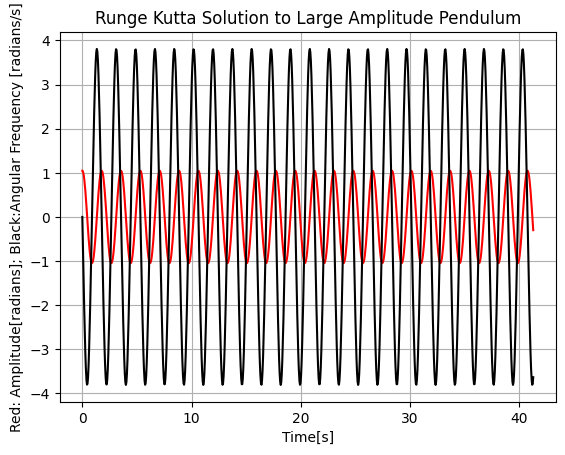

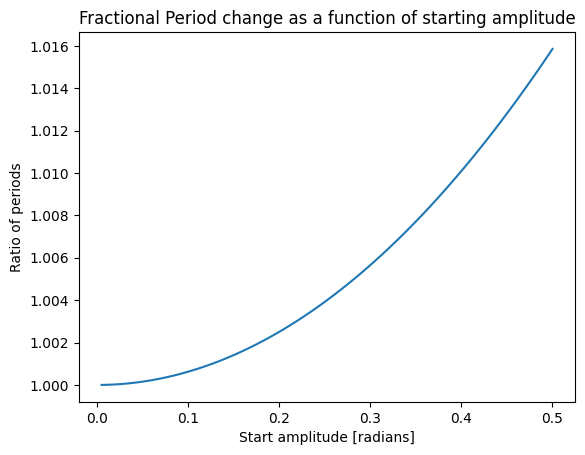

In [11]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import solve_ivp

neval=0

def pend(t,y):
    global neval
    theta, omega = y
    dydt = np.array([omega, - g/l*np.sin(theta)])
    neval=neval+1
    return dydt

#and now we set up some constants (measured quantities)
from scipy.constants import g
omega_0=np.sqrt(g/l)
T=2*np.pi/omega_0  #  period, seconds
theta_0=np.pi/3

#use y0 for the initial conditions
y0 = np.array([theta_0, 0.0])
    
#    We generate a solution 1001 evenly spaced samples in the interval
#    0 <= `t` <= 10.  So our array of times is:

t = np.linspace(0, 25*T, 1001)
    
###    Call `solve_ivp` to generate the solution.  
    
solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,method='DOP853')
print('neval=',neval)
plt.plot(solrk.t, solrk.y[0,:], 'r')
plt.plot(solrk.t, solrk.y[1,:], 'k')
plt.title("Runge Kutta Solution to Large Amplitude Pendulum")
plt.xlabel('Time[s]')
plt.ylabel('Red: Amplitude[radians]; Black:Angular Frequency [radians/s]')
plt.grid()
plt.show()

from scipy.optimize import root

theta_0=np.pi*.1/20.
theta=np.linspace(0.005,0.5, 99)
period=[]
for th in theta:
    y0 = np.array([th, 0.0])
    solrk = solve_ivp(pend,(0,25*T),y0,rtol=1e-11,atol=1e-11,dense_output=True,method='DOP853')
    period.append(root(lambda t:solrk.sol(t)[1],1.0*T).x/T)
period=np.array(period)
plt.plot(theta,period)
plt.title("Fractional Period change as a function of starting amplitude")
plt.xlabel("Start amplitude [radians]")
plt.ylabel("Ratio of periods")
plt.show()

The original equation for the pendulum is:
$$\tau=I\alpha$$ 
$$\tau=-mgl\sin\theta$$
$$I=ml^2$$
so $$\ddot{\theta}=-\frac{g}{l}\sin{\theta}$$ 


We write this second order equation as coupled first order equations:
\begin{equation}
\frac{d}{dt}\left(
\begin{array}{c}
\theta\\
\omega\\
\end{array}
\right)=
\left(
\begin{array}{c}
\omega\\
-\frac{mgl}{I}\sin{\theta}\\
\end{array}\right)
\end{equation}

To add air resistance, we have:
$$\tau=-mgl\sin\theta -l F_D \frac{\dot{\theta}}{|\dot{\theta}|} $$
where $F_D$ is the drag force and the fraction $\frac{\dot{\theta}}{|\dot{\theta}|}$ ensures that the direction of the force is opposite to the velocity of the ball.

Our equation becomes:
\begin{equation}
\frac{d}{dt}\left(
\begin{array}{c}
\theta\\
\omega\\
\end{array}
\right)=
\left(
\begin{array}{c}
\omega\\
-\frac{mgl}{I}\sin{\theta}-\frac {l F_D}{I} \frac{\dot{\theta}}{|\dot{\theta}|} \\
\end{array}\right)
\end{equation}
 
For the drag force, we go back to our smooth sphere drag coefficient interpolation (from the baseball problem)

In [20]:
airPressure=92.6 #kPa
airPressure=101.325
standardAirDensity=1.225 # kg/m**3
standardAirPressure=101.325 #kPa
airDensity=airPressure/standardAirPressure*standardAirDensity
airViscosity=1.827e-5   #Pa-s  

def ReynoldsNumber(velocity):
    '''Calculates Reynolds number. Because it is used 
    in an logarithmic interpolation, we impose 1 as a lower cutoff'''
    R=airDensity*velocity*dMass/airViscosity
    return np.maximum(R,1)

RN=np.array([1,4,10,40,100,400,1000,2000,4000,10000,20000,40000,100000,200000]) # leave out 400000 since it will add wiggles
DC=np.array([24,8,4,1.7,1.1,0.6,0.45,0.4,0.35,0.40,0.45,0.46,0.42,0.39])
import scipy.interpolate
logRN=np.log(RN)  #interpolation in log ReynoldsNumber, and linear in DC will be more sensible
splineInterpolation=scipy.interpolate.interp1d(logRN,DC,kind='cubic')
def DragCoefficient(reynoldsNumber):
    return splineInterpolation(np.log(reynoldsNumber))

def pendDrag(t,y):
    global neval
    theta, omega = y
    RN=ReynoldsNumber(np.abs(l*omega))
    dragForce=0.5*airDensity*(l*omega)**2*np.pi*dMass**2/4*DragCoefficient(RN)*np.sign(omega)
    dydt = np.array([omega, - m*g*l/I*np.sin(theta)-dragForce*l/I])
#    print(theta,omega,RN,dragForce,dydt)
    neval=neval+1
    return dydt


In [21]:
theta_0=np.pi/3
sol=solve_ivp(pendDrag,(0,25*T),[theta_0,0],t_eval=t,rtol=1e-11,method='DOP853')
print(sol)
sol0=solve_ivp(pend,(0,25*T),[theta_0,0],t_eval=t,rtol=1e-11,method='DOP853')

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.126e-02 ...  4.122e+01  4.126e+01]
        y: [[ 1.047e+00  1.036e+00 ... -4.964e-01 -3.855e-01]
            [ 0.000e+00 -5.199e-01 ...  2.554e+00  2.810e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 4454
     njev: 0
      nlu: 0


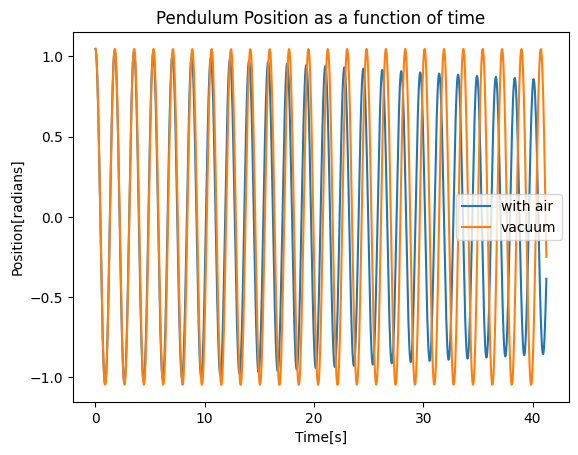

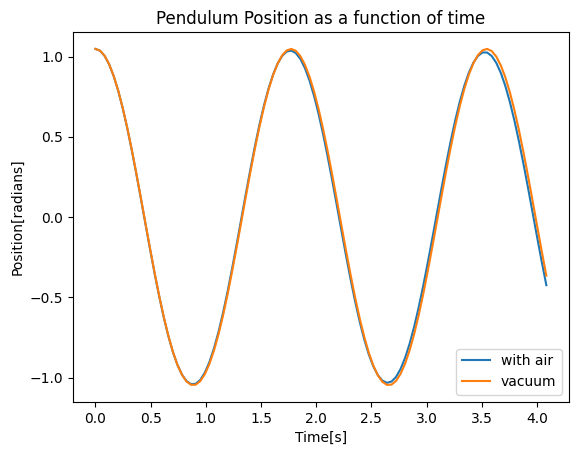

In [22]:
plt.title("Pendulum Position as a function of time")
plt.xlabel("Time[s]")
plt.ylabel('Position[radians]')
    
plt.plot(t,sol.y[0,:],label='with air')
plt.plot(t,sol0.y[0,:],label='vacuum')
plt.legend()
plt.show()
plt.title("Pendulum Position as a function of time")
plt.xlabel("Time[s]")
plt.ylabel('Position[radians]')
plt.plot(t[:100],sol.y[0,:100],label='with air')
plt.plot(t[:100],sol0.y[0,:100],label='vacuum')
plt.legend()
plt.show()

# Air resistance of the string
At this point it is straightforward.  We will do is work it through at a level with which we can determine the size of the systematic uncertainty; and then later we will fit for the overall air resistance in an experiment as a free parameter.

The drag coefficient can be again found in tables- see, for instance, Mark's Engineering Handbook:

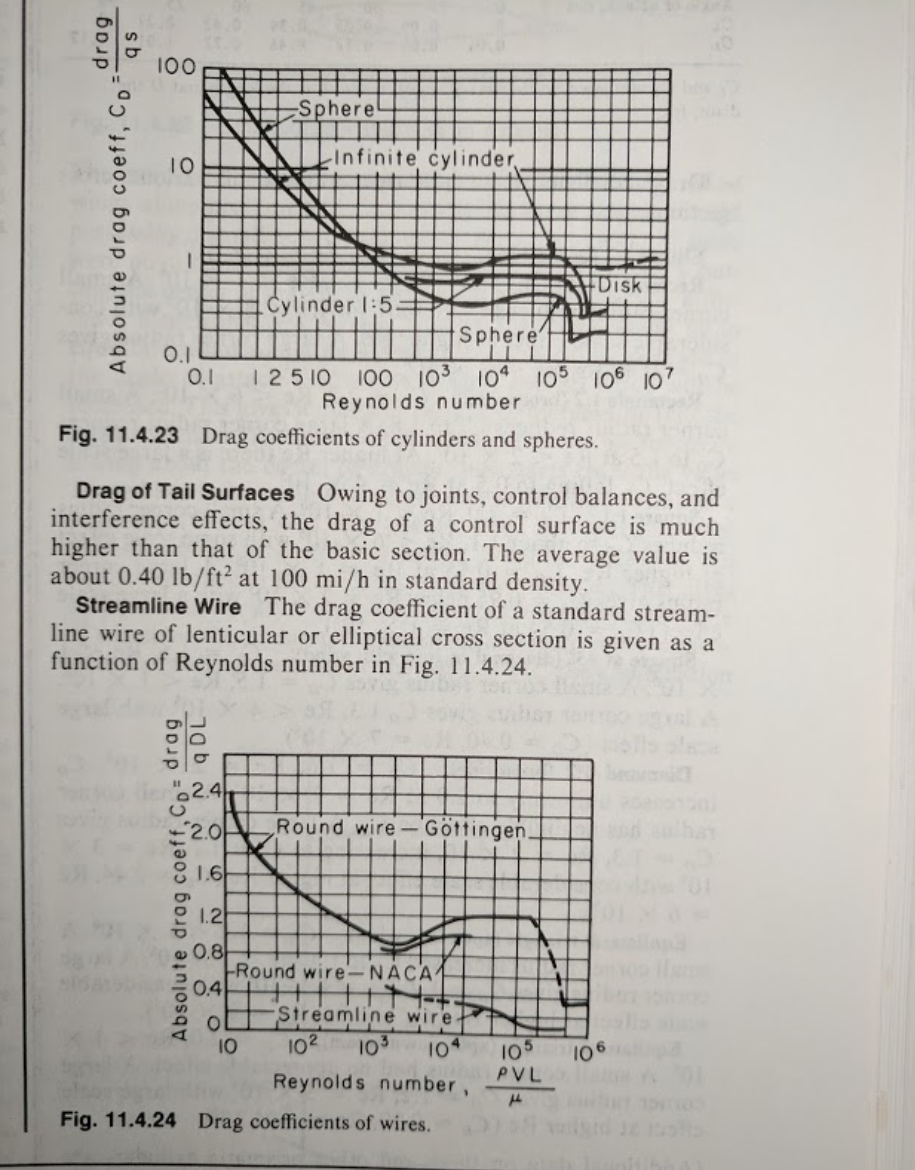
We see that the general magnitude  of drag is roughly the same as for a sphere, but the minimum value for a wire is roughly twice that for a sphere--the minimum value is 0.9 at about R=1000, compared to 0.4 for a sphere.  

We will estimate the ratio of wire drag to sphere drag. 
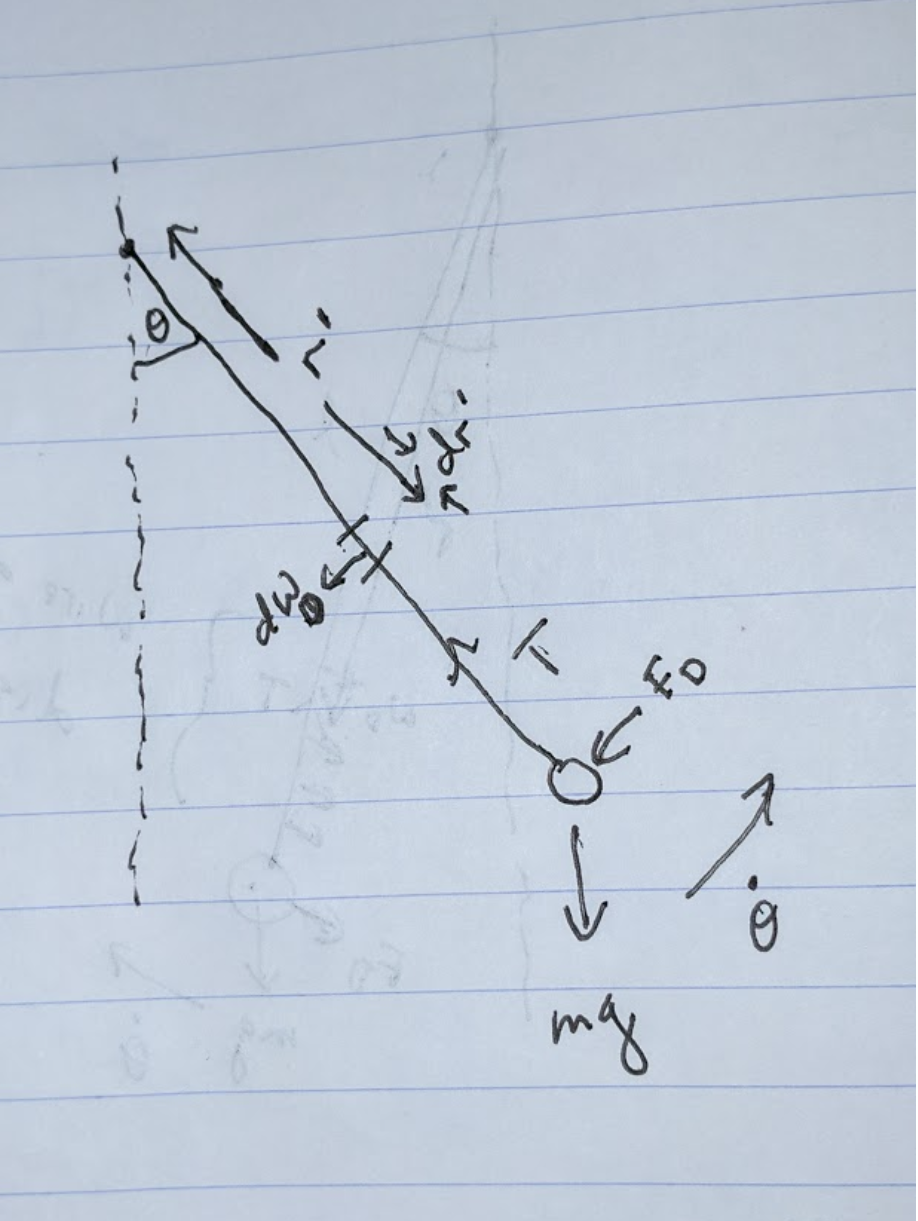

The wire drag, $W_d$ provides an additional torque- at a distance $r'$ from the pivot the wire drag is $dW_d$.  Then the additional torque about the pivot on the wire is $\tau_d=\int_{0}^{l}r'dW_{d}$.  The infinitesimal drag is exactly the same form as the drag on the sphere:
\begin{equation} dW_d=\frac{1}{2}\rho v^2 A C_d=\frac{1}{2}\rho\omega^2 r'^2 Ddr' C_d \end{equation}
\begin{equation}\tau_d= \frac{ D\omega^2\rho}{2}\int_{0}^{l} C_d(r'\omega)r'^3 dr'\approx  \frac{ D\omega^2\rho l^4}{8}<C_d>  \end{equation}
where $D$ is the diameter of the wire.  The torque from air resistance on the sphere is $\frac{\rho l^3 \omega^2 \pi r^2 C_{d,s}}{2}$ and so the ratio of torques is $\frac{D l <C_d>}{4 \pi r^2 C_{d,s}}$.  Plugging in the numbers we get




In [15]:
wireDiameter=stringDiameter #wire diameter, m
ratioWireToSphere=wireDiameter*l/(np.pi*dMass**2)*2  #the final 2 is the assumption of the ratio of drag coefficients
print(ratioWireToSphere)

0.40095805181952915


0.4 is significant so we will do the detailed calculation.

Starting like in the case of the sphere, we read numbers from figure 11.4.24. We will extrapolate the force so that it goes linearly from zero to the first point on our plot.

We start with our interpolation:

wireData: [[2.000e+01 1.880e+00]
 [5.000e+01 1.570e+00]
 [1.000e+02 1.390e+00]
 [2.000e+02 1.250e+00]
 [5.000e+02 1.100e+00]
 [1.000e+03 9.720e-01]
 [2.000e+03 8.760e-01]
 [5.000e+03 9.720e-01]
 [1.000e+04 1.092e+00]
 [2.000e+04 1.164e+00]
 [5.000e+04 1.178e+00]
 [1.000e+05 1.164e+00]]


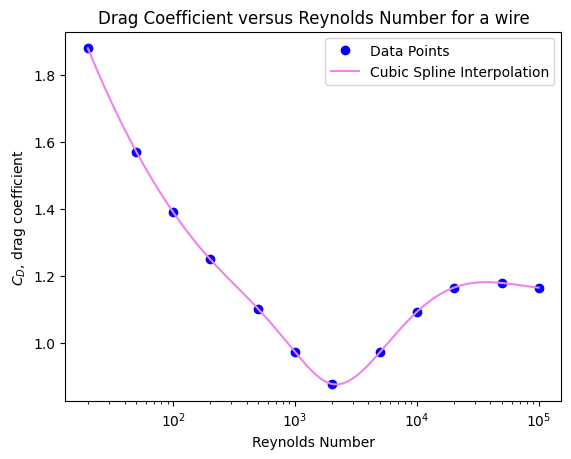

In [16]:
wireData=np.array([20,1.88,50,1.57,100,1.39,200,1.25,500,1.10,1000,.972,2000,.876,5000,.972,10000,1.092,20000,1.164,50000,1.178,100000,1.164]).reshape(12,2)
print('wireData:',wireData)

logWireData=np.log(wireData[:,0])  #interpolation in log ReynoldsNumber will be more sensible
plotXWire=np.logspace(np.log10(wireData[0,0]),np.log10(wireData[-1,0]),100)
interpolation=scipy.interpolate.CubicSpline(logWireData,wireData[:,1])
def DragWire(reynoldsNumber):
    return interpolation(np.log(reynoldsNumber))

plt.figure()
plt.title("Drag Coefficient versus Reynolds Number for a wire")
plt.ylabel(r'$C_D$, drag coefficient')
plt.xlabel("Reynolds Number")
plt.semilogx(wireData[:,0],wireData[:,1],'o',color='blue',label='Data Points')
plt.plot(plotXWire,DragWire(plotXWire),color='violet',label="Cubic Spline Interpolation")
plt.legend();


The next step is to find the $dF_w(v)$- the force on an element of wire of length $dr'$ and radius r (remember the sphere radius r is different!) moving at velocity $v$.  We know 
\begin{equation} dF_w(v)=C_D(R) \frac{\rho v^2 2r dr'}{2}=C_D(\rho v 2r/\eta) \rho v^2 r dr' \end{equation}
for the "fast velocities" (ie. those with Reynolds Number >20).  For slower velocities we will do:
\begin{equation} dF_w(v)=\frac{C_D(20)\rho v_{20}^2}{2v_{20}}v2rdr'  \end{equation} where $v_{20}$ is the velocity that corresponds to a Reynolds Number of 20.  This gives us viscous (proportional to velocity) behaviour and extrapolates into the turbulent flow readily.


The velocity at which Reynolds Number =20 is 0.49714285714285716  m/s


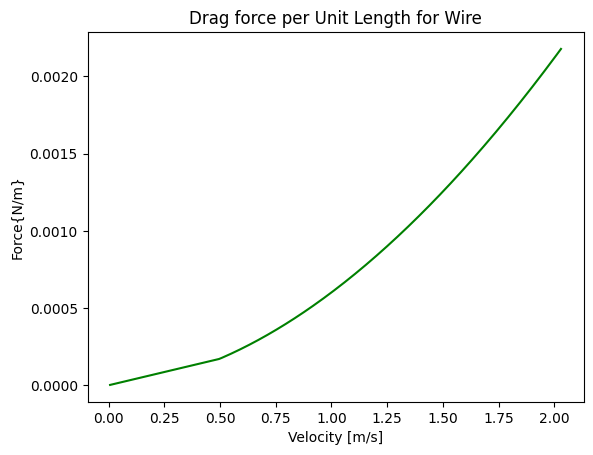

In [17]:
v20=20*airViscosity/(wireDiameter*airDensity)
v20_Coefficient=DragWire(20)*airDensity*v20*wireDiameter/2
print('The velocity at which Reynolds Number =20 is',v20, ' m/s')

def dWireForce(velocity):
    v=np.abs(velocity)  #we make all velocities positive for this calculation and always return a positive force.  
    reynoldsNumber=np.where(v>0,airDensity*v*wireDiameter/airViscosity,1)
    dforce=DragWire(reynoldsNumber)*airDensity*v**2*wireDiameter/2  #units are N/m since we put dz=1
    v20force=v20_Coefficient*v
    return np.where(v<v20,v20force,dforce)

#dWireForce=np.vectorize(dWireForce_Scalar)
plt.figure()
xomega=np.linspace(0,l*3,300)
plt.plot(xomega[1:],dWireForce(xomega[1:]),color='green')
plt.title("Drag force per Unit Length for Wire")
plt.xlabel('Velocity [m/s]')
plt.ylabel('Force{N/m}')
plt.show()

Now integrate

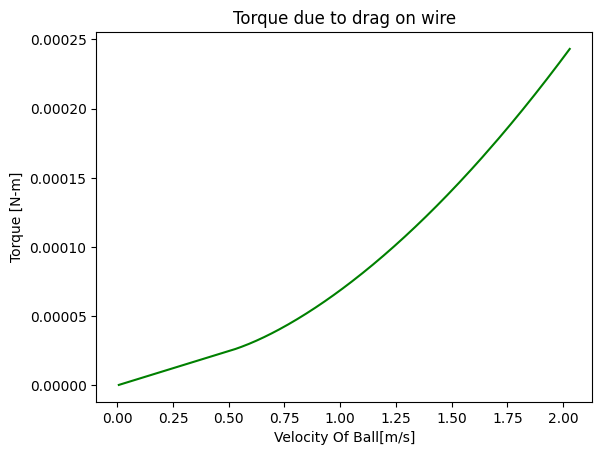

In [18]:
from scipy.integrate import quad

def dTorque(rPrime,omega):
    '''Calculates the torque from an element of wire at rprime moving with angular velocity omega'''
    return rPrime*dWireForce(rPrime*omega)
#vdTorque=np.vectorize(dTorque)

def wireTorque(anOmega):
    om=np.abs(anOmega)
    if(np.isscalar(om)):
        return quad(dTorque,0,stringLength,args=om)[0]
    else:
        retval=np.zeros_like(om)
        for i in np.arange(0,om.size):
            retval[i]=quad(dTorque,0,stringLength,args=om[i])[0]
        return retval
plt.figure()
plt.plot(xomega[1:],wireTorque(xomega[1:]/l),color='green')
plt.title("Torque due to drag on wire")
plt.xlabel('Velocity Of Ball[m/s]')
plt.ylabel('Torque [N-m]');

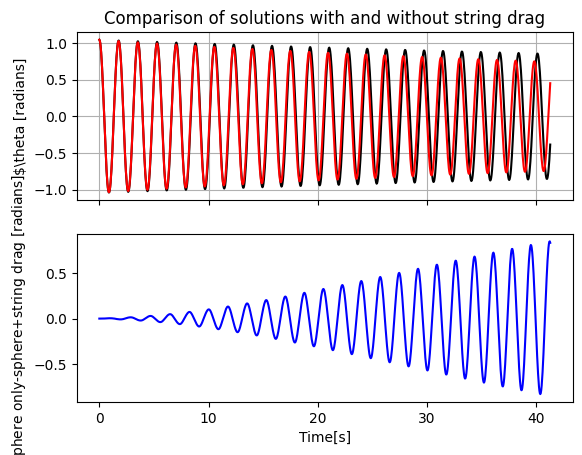

In [23]:
g=9.8
def pendDragString(t,y):
    global neval
    theta, omega = y
    RN=ReynoldsNumber(np.abs(l*omega))
    dragForce=0.5*airDensity*(l*omega)**2*np.pi*dMass**2/4*DragCoefficient(RN)*np.sign(omega)
#    print(theta,omega,RN,dragForce,wireTorque(omega),g)
    dydt = np.array([omega, - m*g*l/I*np.sin(theta)-dragForce*l/I -wireTorque(omega)/I*np.sign(omega)])
#    print(dydt)
    neval=neval+1
    return dydt


#use y0 for the initial conditions
y0 = np.array([theta_0, 0.0])
                     
dragSolutionWithString = solve_ivp(pendDragString,(0,25*T), y0,t_eval=t,method='DOP853')

f, axarr = plt.subplots(2, sharex=True)
axarr[0].set_title('Comparison of solutions with and without string drag')
axarr[0].set_ylabel(r'$\theta [radians]')
axarr[0].plot(t, sol.y[0,:], 'k', label='air drag on mass(t)')
axarr[0].plot(dragSolutionWithString.t, dragSolutionWithString.y[0,:], 'r', label='air drag on string(t)')
axarr[0].grid()
axarr[1].set_xlabel('Time[s]')
axarr[1].set_ylabel(r'sphere only-sphere+string drag $\rm{[radians]}$')
axarr[1].plot(t,dragSolutionWithString.y[0,:]-sol.y[0,:], 'b');

In [ ]:
g

# Adding torque and oscillations of the ball
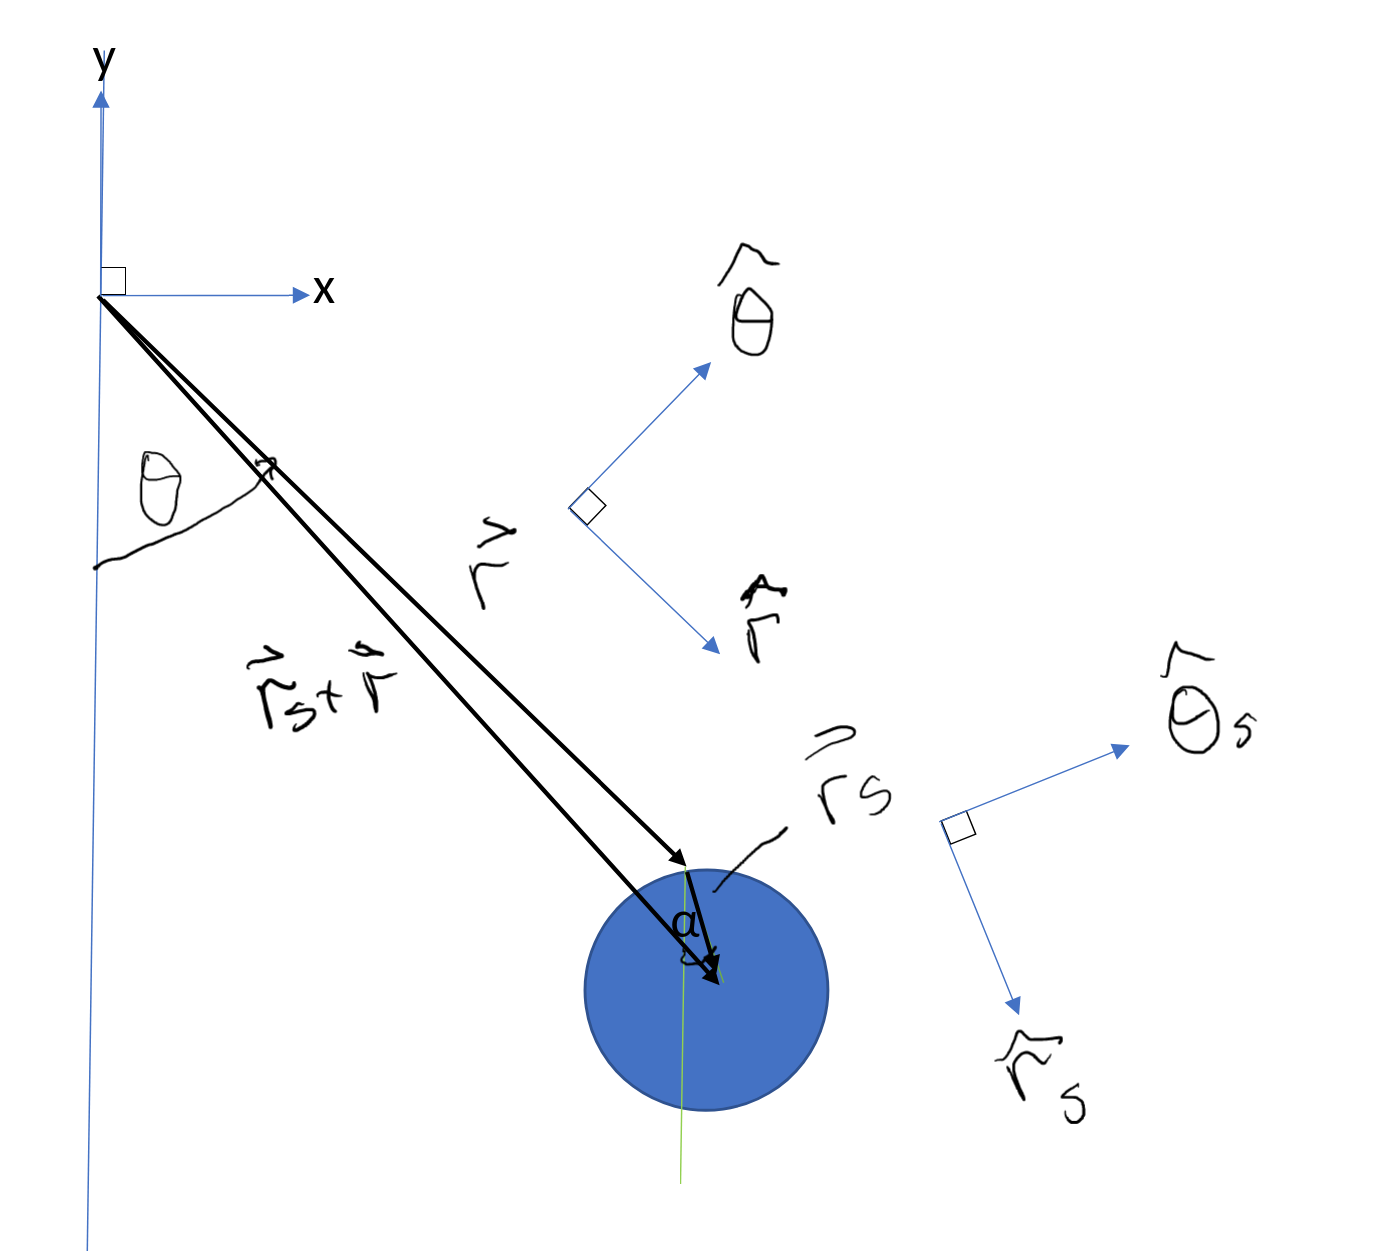

We need to add a second degree of freedom, $\alpha$, the angle between the vertical and the vector from the center of the ball to the string attachment. *Don't confuse this with an angular acceleration!*  Then we have:
$$\begin{align}\vec{r}&=l(\sin\theta,-\cos \theta,0)\equiv l\hat{r}\\
\vec{r_s}&=r_s(\sin\alpha,-\cos\alpha,0)\equiv r_s\hat{r_s}\\
\vec{v}&=l(\cos\theta,\sin \theta,0)\dot{\theta}\equiv l \omega \hat{\theta}\\
\vec{v_s}&=r_s(\cos\alpha,\sin\alpha,0)\dot{\alpha}\equiv r_s \dot{\alpha}\hat{\theta_s}\end{align}$$
where here $\vec{v}$ is the velocity of the tie-point on the ball and $\vec{v_s}$ is the velocity of the ball center with respect to the tie-point.  

Two non-trivial equations of motion come from the $\vec{F}=m\vec{a}$ :
$$\begin{align}-T\hat{r}+m\vec{g}&=m\vec{a}\\&=m\frac{d^2}{dt^2}(\vec{r}+\vec{r_s})\\
&=m\frac{d}{dt}\left(\vec{v}+\vec{v_s}\right) \\&=-lm(\sin\theta,-\cos\theta,0)\dot{\theta}^2+lm(\cos\theta,\sin\theta,0)\ddot{\theta}-r_sm(\sin\alpha,-\cos\alpha,0)\dot{\alpha}^2+r_sm(\cos\alpha,\sin\alpha,0)\ddot{\alpha}\\
&=-ml\omega^2\hat{r}+ml\ddot{\theta}\hat{\theta}-mr_s\dot{\alpha}^2\hat{r_s}+mr_s\ddot{\alpha}\hat{\theta_s} \end{align}$$

while the other comes from the torque about the center of mass of the sphere:
$$-r_s\hat{r_s}\times -T\hat{r}-\frac{2}{5} \frac{m d^2}{4}\ddot{\alpha}(0,0,1)=0\rightarrow \frac{T r_s}{m}\hat{r_s}\times \hat{r}-\frac{d^2}{10} \ddot{\alpha} (0,0,1) =0 $$

Here we don't know $T$, the tension in the string, nor the two double derivatives $\ddot{\theta},\ddot{\alpha}$.  However, at each step of the path, we can solve for it by inverting a matrix, since all three variables appear as a single power.  One could still use root, but it turns out to both take longer and be a little susceptible to starting positions.

In setting this up, we "cheat a little"- in that we use 3 vectors for the force, but the z-coordinate is empty.  In doing the numerics, we put the torques into the empty z-coordinate, giving us a 3x3 matrix in $\ddot\theta,\ddot\alpha,T$ to solve.  The "clean" way to do this would be pull the x, y equations out separately, and then add the torque equation, but we would end up exactly the same.  



So we have a 3x3 matrix (the vectors in the first matrix are column vectors) $$\bf{M}{A}=\bf{B}\rightarrow \bf{A}=\bf{M}^{-1}\bf{B}$$.
$$\begin {pmatrix} -l\hat{\theta} & r_s\hat{\theta}_s-(0,0,\frac{d^2}{10}) & -\hat{r}/m+\hat{r}_s/m \hat{r}_s\times \hat{r} \end{pmatrix} \begin {pmatrix} \ddot{\theta}\\ \ddot{\alpha} \\T \end{pmatrix}= \begin {pmatrix}-\vec{g}-l\omega^2\hat{r}-r_s\dot{\alpha}^2\hat{r_s}\end{pmatrix}$$

In [23]:
from scipy.optimize import root

import scipy.constants

g=np.array([0,-1,0])*scipy.constants.g 
rs=dMass/2

def phyPend(t,y):
    theta,omega,alpha,alphadot=y
    hatr=np.array([np.sin(theta),-np.cos(theta),0]) #unit vector along pivot->ball center
    hatrs=np.array([np.sin(alpha),-np.cos(alpha),0])
    hattheta=np.array ([-hatr[1],hatr[0],0])
    hatthetas=np.array([-hatrs[1],hatrs[0],0])
    ar=np.array([-l*hattheta,-rs*hatthetas-np.array([0,0,0.1*dMass**2]),-hatr/m+rs/m*np.cross(hatrs,hatr)]).transpose()
    arinverse=np.linalg.inv(ar)
    B=-g-l*omega**2*hatr-rs*alphadot**2*hatrs
    B.transpose()            
    sol=arinverse@B
    return np.array([y[1],sol[0],y[3],sol[1]])

y0=np.array([theta_0,0,0,0])  # pendulum pulled to side, but not rotated (alpha=0)
solution= solve_ivp(phyPend,(0,25*T), y0,rtol=1e-11,method='DOP853')


In [24]:
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.595e-03 ...  4.126e+01  4.126e+01]
        y: [[ 1.047e+00  1.047e+00 ...  6.167e-01  6.052e-01]
            [ 0.000e+00 -5.497e-02 ... -2.828e+00 -2.918e+00]
            [ 0.000e+00  1.881e-03 ... -1.399e-01 -1.874e-01]
            [ 0.000e+00  1.047e+00 ... -1.372e+01 -1.002e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 102602
     njev: 0
      nlu: 0

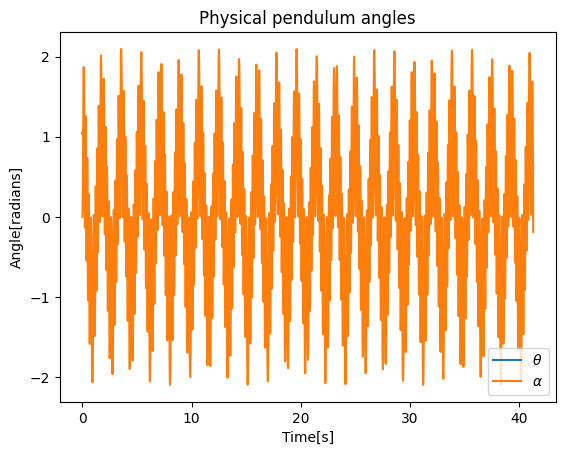

In [25]:
#plt.plot(t,solution.t)
plt.plot(solution.t,solution.y[0,:],label=r'$\theta$')
plt.plot(solution.t,solution.y[2,:],label=r'$\alpha$')
plt.title("Physical pendulum angles")
plt.legend()
plt.xlabel("Time[s]")
plt.ylabel("Angle[radians]")
plt.show()


In [26]:
n=20
t2=np.linspace(0,n*T,2048)
sol2=solve_ivp(phyPend,(0,n*T),y0,t_eval=t2,method='DOP853',rtol=1e-11)

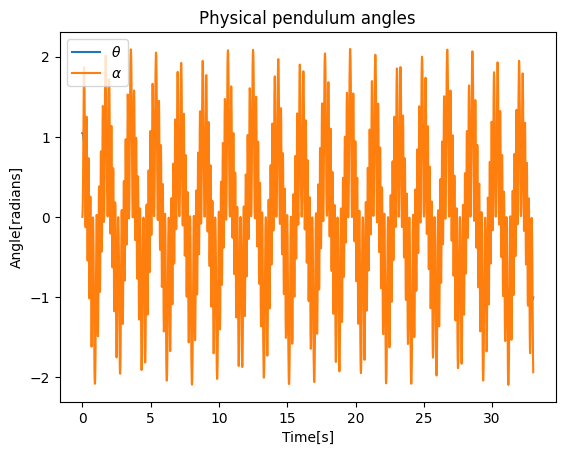

In [28]:
plt.plot(sol2.t,sol2.y[0,:],label=r'$\theta$')
plt.plot(sol2.t,sol2.y[2,:],label=r'$\alpha$')
plt.title("Physical pendulum angles")
plt.legend()
plt.xlabel("Time[s]")
plt.ylabel("Angle[radians]")
plt.show()

#  A bit of Fourier analysis

There are routines in scipy that allow you to do straightforward Fourier transforms.  In particular there is a scipy.fft that is a "base algorithm" and just does the normal fourier transform.  To use it in a given problem there are several technicalities that you need to pay attention to.  However, there are specific algorithms that do things that one uses Fourier transforms for, such as finding the "power spectrum".  We will use scipy.signal.periodogram to look at the power in the theta and alpha distributions; we will actually calculate in terms of derivatives, since the "power" is actually the "square of the input"

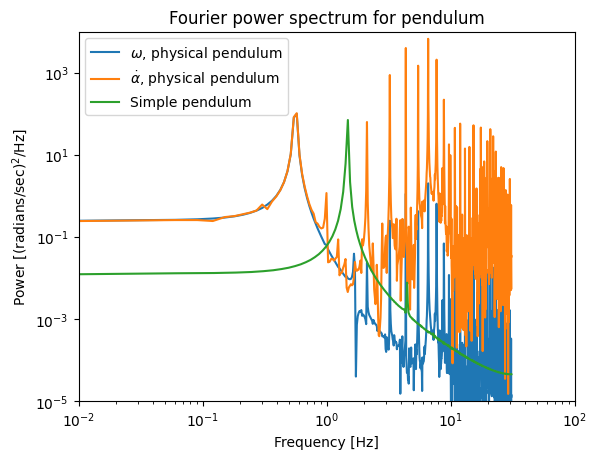

In [29]:
from scipy.signal import periodogram
#from scipy.fft import fft,fftshift
f,Pxx=periodogram(sol2.y[1,:],1.0/sol2.t[1])
f2,Pxx2=periodogram(sol2.y[3,:],1.0/sol2.t[1])
f3,Pxx3=periodogram(dragSolutionWithString.y[1,:],1.0/sol2.t[1])

plt.ylim(1e-5, 10000)
plt.xlim(0.01,100)
plt.loglog(f,Pxx,label='$\omega$, physical pendulum')
plt.loglog(f2,Pxx2,label=r'$\dot{\alpha}$, physical pendulum')
plt.loglog(f3,Pxx3,label='Simple pendulum')
plt.title("Fourier power spectrum for pendulum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [(radians/sec)$^2$/Hz]")
plt.legend()
plt.show()